In [5]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from sklearn.tree import DecisionTreeClassifier

In [19]:
rng = np.random.default_rng(123)

X = rng.uniform(0, 1, size=(1000, 1))
y = np.sin(2 * np.pi * 3 * X[:, 0]) + 13 + 42 + rng.normal(0, 0.1, size=X.shape[0])

X[:5], y[:5]

(array([[0.68235186],
        [0.05382102],
        [0.22035987],
        [0.18437181],
        [0.1759059 ]]),
 array([55.17843954, 55.78492855, 54.27152673, 54.79596119, 54.77863012]))

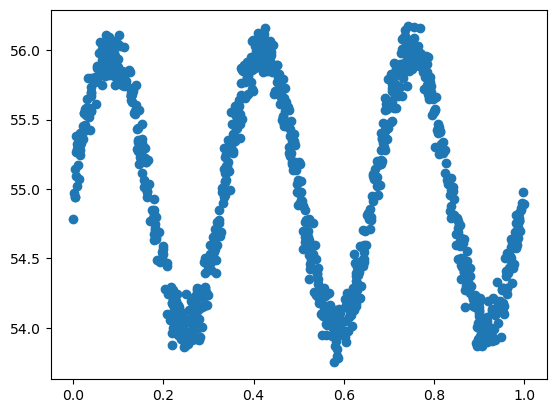

In [20]:
plt.scatter(X[:, 0], y);

In [21]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
from sklearn.preprocessing import SplineTransformer

X_hat = SplineTransformer(n_knots=40, degree=1).fit_transform(X)
model.fit(X_hat,y)
preds = model.predict(X_hat)

x = X[:, 0]
b = np.mean(y)
a = np.sum((y-b) * x) / (2 * np.sum(x * x)) 
a, b

(np.float64(-0.07511851895119012), np.float64(54.9950028375315))

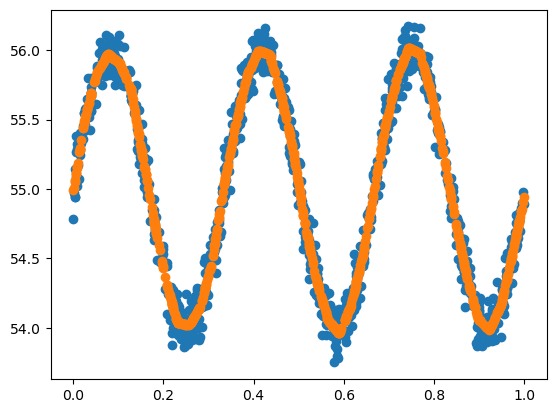

In [ ]:
plt.scatter(X[:, 0], y)
plt.scatter(X[:, 0], preds);

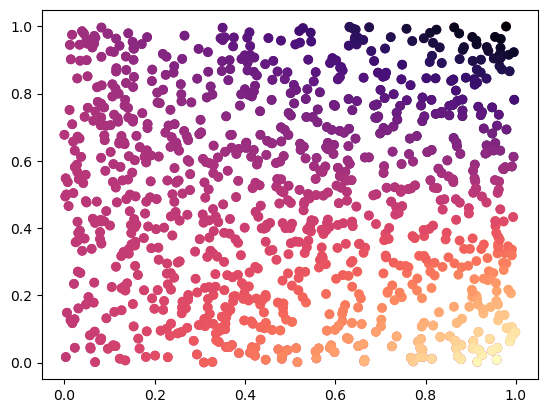

In [48]:
from sklearn.preprocessing import PolynomialFeatures


X = rng.uniform(0, 1, size=(1000, 2))
y = np.sin(X[:, 0]) * np.sin(2 * np.pi * X[:, 1])
X_hat = PolynomialFeatures(degree=2).fit_transform(X)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='magma');

model.fit(X_hat, y)
preds = model.predict(X_hat)
plt.scatter(X[:, 0], X[:, 1], c=preds, cmap='magma');

(1000, 6)